In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker
import cartopy.feature as feature
import matplotlib.colors as colors

from matplotlib.colors import TwoSlopeNorm
from matplotlib.colors import LinearSegmentedColormap
from cartopy.util import add_cyclic_point
from cartopy.mpl.ticker import (LongitudeFormatter, LatitudeFormatter)

from scipy.stats import ttest_ind

In [2]:
# --- read mask

# input mask - Miocene
ds_mask = xr.open_dataset('../Miocene_LANDFRAC.nc')
var = 'LANDFRAC'
mask = ds_mask[var][0,:,:]
# Add cyclic point to mask
mask_Mio, lons = add_cyclic_point(mask, coord=ds_mask['lon'])

# ==================================================================
# input mask - Preindustrial
ds_mask = xr.open_dataset('../Preindustrial_LANDFRAC.nc')
var = 'LANDFRAC'
mask = ds_mask[var][0,:,:]
# Add cyclic point to mask
mask_Pi, lons = add_cyclic_point(mask, coord=ds_mask['lon'])

In [3]:
lat = ds_mask['lat']
lon = ds_mask['lon']
weights = np.cos(np.deg2rad(lat))

## net TOA Radiation

In [4]:
# --- read data --- 
ds = xr.open_dataset('./FigS4_FCM_NetTOA.nc')

# --- input variables ---

FCM_Pi_toa = ds['FCM_Pi_toa']
FCM_Mio_toa = ds['FCM_Mio_toa']

In [5]:
toa_evo = np.empty((8, lat.size, lon.size))
toa_evo = xr.DataArray(data=toa_evo, dims=['period','lat','lon'], 
                       coords=[[1,2,3,4,1,2,3,4], lat, lon])

toa_evo[0,:,:] = FCM_Pi_toa[0,:,:]
toa_evo[1,:,:] = FCM_Pi_toa[1,:,:]
toa_evo[2,:,:] = FCM_Pi_toa[2,:,:]
toa_evo[3,:,:] = FCM_Pi_toa[3,:,:]
toa_evo[4,:,:] = FCM_Mio_toa[0,:,:]
toa_evo[5,:,:] = FCM_Mio_toa[1,:,:]
toa_evo[6,:,:] = FCM_Mio_toa[2,:,:]
toa_evo[7,:,:] = FCM_Mio_toa[3,:,:]

# Add cyclic point to data
data = toa_evo
data, lons = add_cyclic_point(data, coord=lon)

''

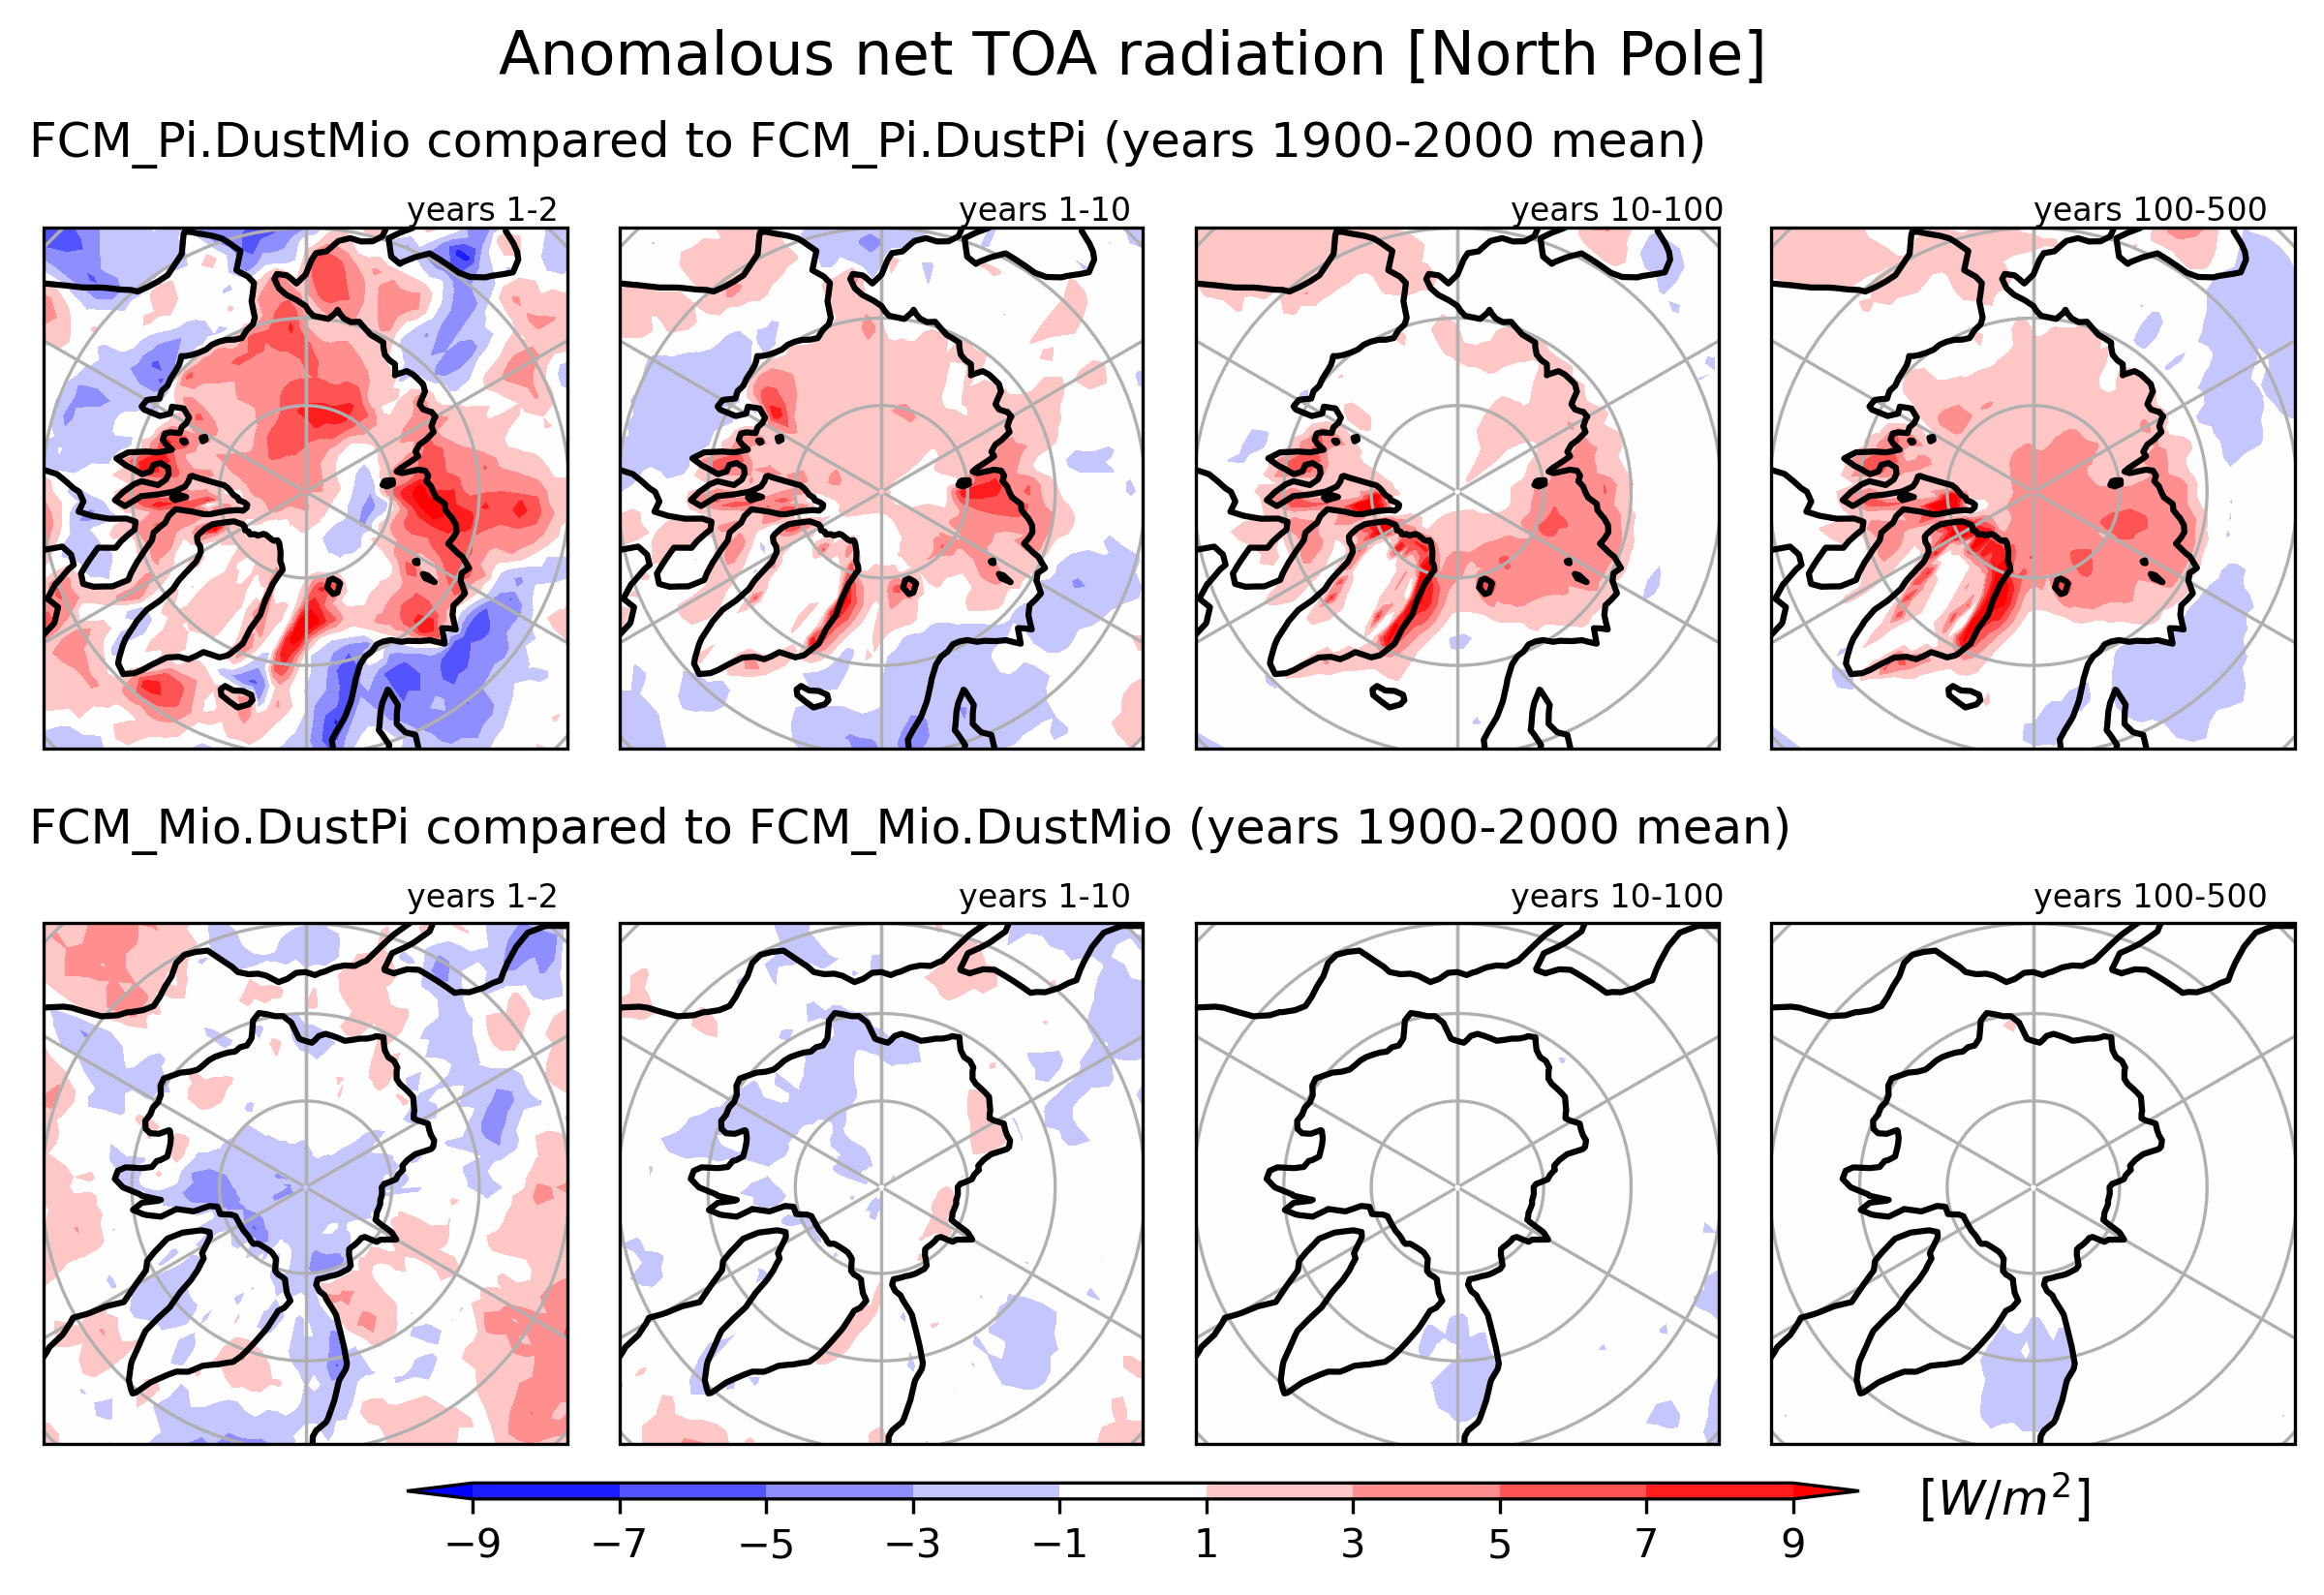

In [7]:
# --- plot ---

rwb = LinearSegmentedColormap.from_list(
    'custom_rwb',
    ['blue', 'white', 'red'],  # order matters!
    N=256  # number of color levels
)
rwb.set_bad(color='white')


# Define the figure and each axis for the 4 rows and 3 columns
fig, axs = plt.subplots(nrows=2,ncols=4,subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=0)},
                        figsize=(10,5.5), dpi=300)

# Set Width / Height padding between subplots, expressed as a fraction of the subplot width
fig.subplots_adjust(wspace=0.1, hspace=0.3) 
    
# axs is a 2 dimensional array of `GeoAxes`
# flatten it into a 1-D array
axs=axs.flatten()
    
# Loop over all of the months and plot
for i,m in enumerate(toa_evo['period']):
        
    # Contour plot
    if i < 4:
        cs2=axs[i].contourf(lons,lat,data[i,:,:], levels = np.linspace(-9, 9, 10),
                            transform = ccrs.PlateCarree(), cmap=rwb, extend='both')
        axs[i].contour(lons, lat, mask_Pi, [0.6,1.1], transform = ccrs.PlateCarree(),
                       colors='k', linewidths=1.5, zorder=3)
        # axs[i].contour(lons, lat, mask_Mio, [0.6,1.2], transform = ccrs.PlateCarree(),
        #                colors='darkgrey', linewidths=1.5, zorder=4)
    
    else:
        cs2=axs[i].contourf(lons,lat,data[i,:,:], levels = np.linspace(-9, 9, 10),
                            transform = ccrs.PlateCarree(), cmap=rwb, extend='both')
        # Add coastines in Miocene Scenario
        axs[i].contour(lons, lat, mask_Mio, [0.6,1.2], transform = ccrs.PlateCarree(),
                       colors='k', linewidths=1.5, zorder=4)
    
    axs[i].set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())  
                  
    # Add gridlines
    axs[i].gridlines(crs=ccrs.PlateCarree(), 
                     y_inline=True, ylocs=range(0,90,10),
                     colors='white', zorder=2)

        
# Add colorbar
cax2 = fig.add_axes([0.25, 0.08, 0.5, 0.01])    # set the [x0, y0, width, height] of the colorbar
CB2  = plt.colorbar(cs2, cax=cax2, orientation='horizontal')

plt.figtext(0.12,0.92,'FCM_Pi.DustMio compared to FCM_Pi.DustPi (years 1900-2000 mean)',fontsize=12)
plt.figtext(0.25,0.88,'years 1-2',fontsize=8)
plt.figtext(0.44,0.88,'years 1-10',fontsize=8)
plt.figtext(0.63,0.88,'years 10-100',fontsize=8)
plt.figtext(0.81,0.88,'years 100-500',fontsize=8)
plt.figtext(0.12,0.49,'FCM_Mio.DustPi compared to FCM_Mio.DustMio (years 1900-2000 mean)',fontsize=12)
plt.figtext(0.25,0.45,'years 1-2',fontsize=8)
plt.figtext(0.44,0.45,'years 1-10',fontsize=8)
plt.figtext(0.63,0.45,'years 10-100',fontsize=8)
plt.figtext(0.81,0.45,'years 100-500',fontsize=8)


# Add colobar's title
plt.figtext(0.8,0.07,'$[W/m^2]$',ha='center',fontsize=12)
# Add title
plt.suptitle('Anomalous net TOA radiation [North Pole]', y=1.00, fontsize=15)
# fig.savefig('plot_TS.png')
;